In [1]:
import time
import numpy as np
from scipy.stats import skewnorm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import EL
import pickle
import statsmodels.api as sm
sns.set()

/Users/jiguangli/opt/anaconda3/envs/EL/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Conditional Moment Conditions Simulations

## Example 1 in https://arxiv.org/abs/2110.13531




Suppose that
\begin{equation}
\mathbb{E}^P\!\left[(Y - \theta_0 - \theta_1 X)\mid Z\right] = 0,
\end{equation}
where $\rho(X,\theta) = (Y - \theta_0 - \theta_1 X)$, $Z = (1,X)$, and $d = 1$.
This conditional moment (CM) model is consistent with the data generating process (DGP)

$$Y = \theta_0 + \theta_1 X + \varepsilon,$$


where $\varepsilon = h(X)U$, and $(X,U)$ (independent) follow some unknown distribution $P$, with
$\mathbb{E}(U)=0$, and the heteroscedasticity function $h(X)$ is unknown.


We create a set of simulated data
$\{y_i,x_i\}_{i=1}^n$, $n=250$, with covariates $X\sim U(-1,2.5)$, intercept $\theta_0=1$,
slope $\theta_1=1$, and $\varepsilon_i$ distributed according to

$$\varepsilon_i \sim \mathrm{SN}(m(x_i),h(x_i),s(x_i)),$$

where $\mathrm{SN}(m,h,s)$ is the skew-normal distribution with location, scale, and shape
parameters given by $(m,h,s)$, each depending on $x_i$. When $s=0$, $\varepsilon_i$ is normal
with mean $m$ and standard deviation $h$.
We set

$$m(x_i) = -h(x_i)\sqrt{\tfrac{2}{\pi}}\,\frac{s(x_i)}{\sqrt{1+s(x_i)^2}},$$

so that $\mathbb{E}^P[\varepsilon\mid X]=0$.

Suppose that

$$h(x) = \sqrt{\exp(1 + 0.7x + 0.2x^2)}
\quad \text{and} \quad
s(x) = 1 + x^2.
$$
Model parameters are estimated solely from the condition
$\mathbb{E}^P[\varepsilon\mid Z]=0$, $Z=(1,X)$.

The posterior is computed for $K$ given by $2$, $2n^{1/6}=5$, $10$, $15$ and $20$
(the value $2n^{1/6}$ is based on the theory below for splines approximating functions).

For $k= \{2,5,10,15,20\}$, we compute the posterior mean, standard deviation, median, lower ($5\%$) quantile, and upper quantile ($95\%$) for both $\theta_0$ and $\theta_1$

In [2]:
def simulate_data(n: int = 250, seed: int = 42, theta0: float = 1.0, theta1: float = 1.0):
    """
    DGP:
      X ~ U(-1, 2.5)
      Y = theta0 + theta1 X + eps
      eps | X ~ SkewNormal(loc=m(X), scale=h(X), shape=s(X))
      with m(X) chosen so E[eps|X]=0.

    h(x) = sqrt(exp(1 + 0.7x + 0.2x^2))
    s(x) = 1 + x^2
    m(x) = -h(x)*sqrt(2/pi)* s(x)/sqrt(1+s(x)^2)
    """
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 2.5, size=n)

    h = np.sqrt(np.exp(1.0 + 0.7 * x + 0.2 * x**2))
    s = 1.0 + x**2
    delta = s / np.sqrt(1.0 + s**2)
    m = -h * np.sqrt(2.0 / np.pi) * delta  # ensures E[eps|X]=0

    eps = skewnorm.rvs(a=s, loc=m, scale=h, size=n, random_state=rng)
    y = theta0 + theta1 * x + eps
    return y, x

def ols_start(y: np.ndarray, x: np.ndarray) -> np.ndarray:
    """OLS start for y ~ 1 + x."""
    Xdesign = np.column_stack([np.ones_like(x), x])
    beta, *_ = np.linalg.lstsq(Xdesign, y, rcond=None)
    return beta.astype(float)

def g_residual(data: np.ndarray, theta: np.ndarray) -> np.ndarray:
    """
    Base (scalar) moment: residual.
    Conditional restriction:
        E[ residual | X ] = 0
    will be handled by ConditionGenELV2 via basis expansion b^K(W) ⊗ residual.
    """
    y = data[:, 0]
    x = data[:, 1]
    return y - theta[0] - theta[1] * x  # shape (n,)

def summarize_draws(thetas: np.ndarray) -> dict:
    """Posterior summaries for theta0/theta1."""
    out = {}
    names = ["theta0", "theta1"]
    for j, nm in enumerate(names):
        a = thetas[:, j]
        out[nm] = {
            "mean": float(np.mean(a)),
            "sd": float(np.std(a, ddof=1)),
            "median": float(np.median(a)),
            "q05": float(np.quantile(a, 0.05)),
            "q95": float(np.quantile(a, 0.95)),
        }
    return out

def print_summary_table(stats: dict, K: int):
    """Pretty print the summary stats."""
    print(f"Posterior summaries for K={K}:")
    header = f"{'param':<8}  {'mean':>10}  {'sd':>10}  {'median':>10}  {'q05':>10}  {'q95':>10}"
    print(header)
    print("-" * len(header))
    for nm in ["theta0", "theta1"]:
        s = stats[nm]
        print(
            f"{nm:<8}  "
            f"{s['mean']:>10.4f}  {s['sd']:>10.4f}  {s['median']:>10.4f}  "
            f"{s['q05']:>10.4f}  {s['q95']:>10.4f}"
        )
    print()


def build_model_for_K(
    y: np.ndarray,
    x: np.ndarray,
    K: int,
    B: int,
    random_state: int = 42,
):
    """
    Map requested K to ConditionGenELV2 basis settings.

    IMPORTANT NOTE: we assume K >=3

    Strategy used here:
      - Always include an explicit constant basis column (add_constant=True),
        so theta0 is identified robustly.
      - For K >= 5, we set df_first = K-1 to get total K_eff = 1 + (K-1) = K.
  
    """
    n = len(x)
    data = np.column_stack([y, x])
    W = x.reshape(-1, 1)  # conditioning variable is X (constant in Z is redundant)

    theta_init = ols_start(y, x)

    # total K = const + (K-1) spline cols
    df_first = max(3, K - 1)
    whiten_basis = True
    max_moment_ratio = 0.90
    add_constant = True

    model = EL.ConditionGenELV2(
        X=data,
        W=W,
        g=g_residual,
        theta0=theta_init,

        # basis controls
        df_first=df_first,
        df_rest=3,  # irrelevant for 1D W
        center_basis=True,
        scale_basis=True,
        add_constant=add_constant,
        whiten_basis=whiten_basis,
        svd_tol=1e-12,
        max_moment_ratio=max_moment_ratio,

        # GenELV2 controls (BB only)
        init_theta="ETEL",     # start from OLS; set "etel" if you want extra robustness
        alpha=0.0,
        m=0,
        B_nums=B,
        random_state=random_state,

        bounds=None,
        newton_tol=1e-8,
        newton_maxiter=100,
        newton_ridge=1e-8,

        # For conditional (q can be moderate), SC-Newton is usually fast; it’s safe due to fallback.
        use_sc_newton=True,
        enable_penalized=False,
        lam_max=1e4,
        per_v_gmm_start=True,
    )

    return model


def run_experiment(n=250, B=20000, Ks=(3, 5), seed_data=42, seed_boot=42):
    """
    Run conditional GenELV2 for each K and print posterior summaries.
    """
    y, x = simulate_data(n=n, seed=seed_data, theta0=1.0, theta1=1.0)
    beta_ols = ols_start(y, x)

    print(f"n={n}")
    print(f"True theta:  theta0=1.0000, theta1=1.0000")
    print(f"OLS  theta:  theta0={beta_ols[0]:.4f}, theta1={beta_ols[1]:.4f}")
    print(f"Bootstrap draws B={B}")
    print()
    result = {}
    for K in Ks:
        model = build_model_for_K(y=y, x=x, K=K, B=B, random_state=seed_boot)
        t0 = time.perf_counter()
        res = model.fit(
            store_weights=False,
            store_b_weights=False,
            maxiter=100,
            ftol=1e-8,
            eps=1e-6,
        )
        # res = model.fit_in_parallel(
        #     max_workers= 8
        # )
        t1 = time.perf_counter()
        elapsed = t1 - t0
        draws_per_sec = B / elapsed if elapsed > 0 else np.nan
        result[K] = {"thetas":res.thetas, "success": res.success}
        stats = summarize_draws(res.thetas)
        print(K)
        print(f"Time: {elapsed:.2f} sec  ({draws_per_sec:.1f} draws/sec)")
        print_summary_table(stats, K=K)
        with open("GenEL_K_draws.pkl", "wb") as f:
            pickle.dump(result, f)


In [3]:
with open("GenEL_K_draws.pkl", "rb") as f:
    samples = pickle.load(f)

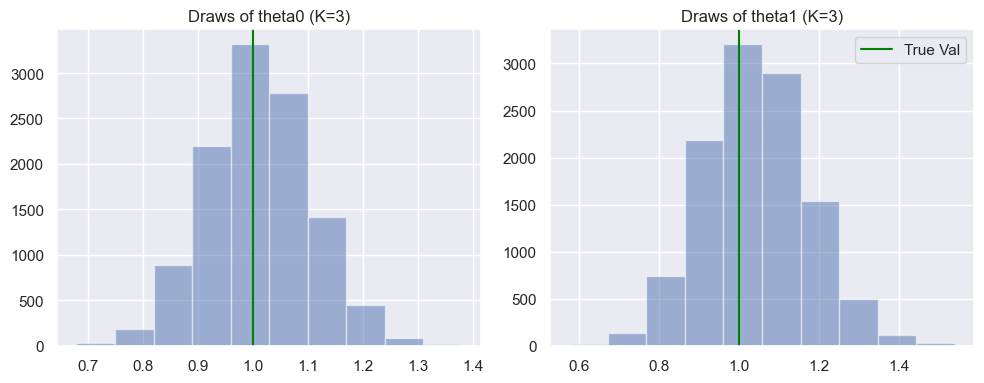

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
K = 3
thetas = samples[K]["thetas"]
successes = samples[K]["success"]
thetas = thetas[successes]
axes[0].hist(thetas[:, 0], alpha=0.5)
axes[0].set_title(f"Draws of theta0 (K={K})")
axes[0].axvline(x=1, label= "True Val", color= "green")

axes[1].hist(thetas[:, 1], alpha=0.5)
axes[1].set_title(f"Draws of theta1 (K={K})")
axes[1].axvline(x=1, label= "True Val", color= "green")
plt.tight_layout()
plt.legend()
plt.show()

In [5]:
stats = summarize_draws(thetas)
print_summary_table(stats, K=K)

Posterior summaries for K=3:
param           mean          sd      median         q05         q95
--------------------------------------------------------------------
theta0        1.0113      0.0946      1.0101      0.8578      1.1687
theta1        1.0425      0.1295      1.0401      0.8366      1.2577



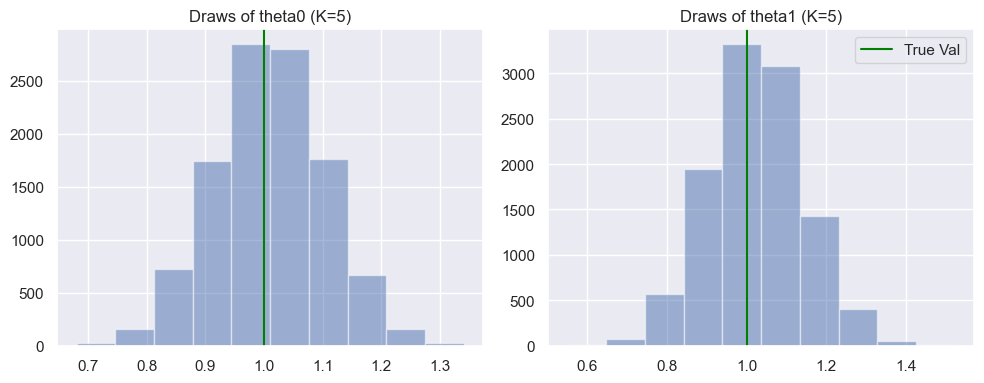

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
K = 5
thetas = samples[K]["thetas"]
successes = samples[K]["success"]
thetas = thetas[successes]
axes[0].hist(thetas[:, 0], alpha=0.5)
axes[0].set_title(f"Draws of theta0 (K={K})")
axes[0].axvline(x=1, label= "True Val", color= "green")

axes[1].hist(thetas[:, 1], alpha=0.5)
axes[1].set_title(f"Draws of theta1 (K={K})")
axes[1].axvline(x=1, label= "True Val", color= "green")
plt.tight_layout()
plt.legend()
plt.show()

In [7]:
stats = summarize_draws(thetas)
print_summary_table(stats, K=K)

Posterior summaries for K=5:
param           mean          sd      median         q05         q95
--------------------------------------------------------------------
theta0        1.0104      0.0940      1.0097      0.8580      1.1655
theta1        1.0234      0.1181      1.0229      0.8323      1.2207



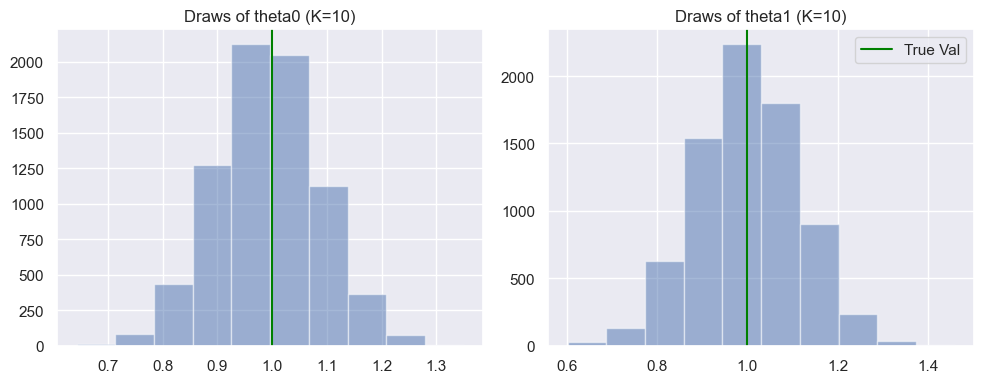

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
K = 10
thetas = samples[K]["thetas"]
successes = samples[K]["success"]
thetas = thetas[successes]
axes[0].hist(thetas[:, 0], alpha=0.5)
axes[0].set_title(f"Draws of theta0 (K={K})")
axes[0].axvline(x=1, label= "True Val", color= "green")

axes[1].hist(thetas[:, 1], alpha=0.5)
axes[1].set_title(f"Draws of theta1 (K={K})")
axes[1].axvline(x=1, label= "True Val", color= "green")
plt.tight_layout()
plt.legend()
plt.show()

In [9]:
stats = summarize_draws(thetas)
print_summary_table(stats, K=K)

Posterior summaries for K=10:
param           mean          sd      median         q05         q95
--------------------------------------------------------------------
theta0        0.9917      0.0925      0.9921      0.8412      1.1442
theta1        1.0013      0.1134      1.0010      0.8160      1.1872



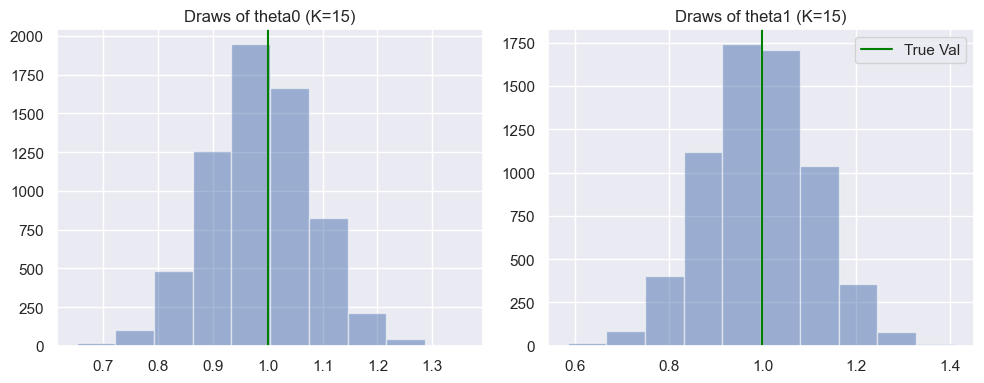

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
K = 15
thetas = samples[K]["thetas"]
successes = samples[K]["success"]
thetas = thetas[successes]
axes[0].hist(thetas[:, 0], alpha=0.5)
axes[0].set_title(f"Draws of theta0 (K={K})")
axes[0].axvline(x=1, label= "True Val", color= "green")

axes[1].hist(thetas[:, 1], alpha=0.5)
axes[1].set_title(f"Draws of theta1 (K={K})")
axes[1].axvline(x=1, label= "True Val", color= "green")
plt.tight_layout()
plt.legend()
plt.show()

In [11]:
stats = summarize_draws(thetas)
print_summary_table(stats, K=K)

Posterior summaries for K=15:
param           mean          sd      median         q05         q95
--------------------------------------------------------------------
theta0        0.9859      0.0922      0.9857      0.8359      1.1357
theta1        0.9932      0.1136      0.9933      0.8062      1.1792



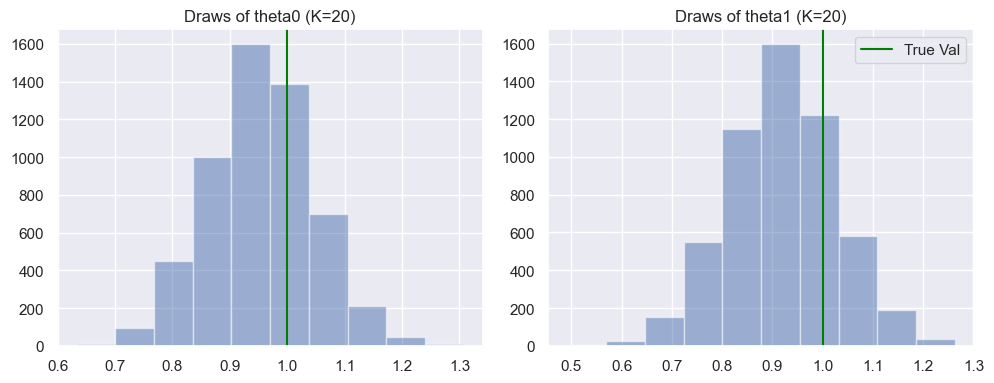

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
K = 20
thetas = samples[K]["thetas"]
successes = samples[K]["success"]
thetas = thetas[successes]
axes[0].hist(thetas[:, 0], alpha=0.5)
axes[0].set_title(f"Draws of theta0 (K={K})")
axes[0].axvline(x=1, label= "True Val", color= "green")

axes[1].hist(thetas[:, 1], alpha=0.5)
axes[1].set_title(f"Draws of theta1 (K={K})")
axes[1].axvline(x=1, label= "True Val", color= "green")
plt.tight_layout()
plt.legend()
plt.show()

In [13]:
stats = summarize_draws(thetas)
print_summary_table(stats, K=K)

Posterior summaries for K=20:
param           mean          sd      median         q05         q95
--------------------------------------------------------------------
theta0        0.9535      0.0912      0.9537      0.8030      1.1029
theta1        0.9199      0.1078      0.9197      0.7438      1.0996

